Dataset Head:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset Shape:
(150, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   s

/tmp/ipykernel_5399/1765337457.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sepal length (cm)'].fillna(
/tmp/ipykernel_5399/1765337457.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

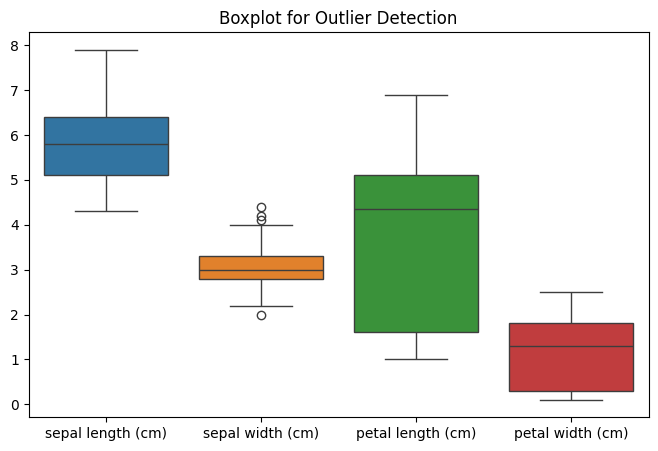


Dataset Shape After Removing Outliers:
(145, 5)

Encoded Dataset Head:
  species  species_encoded
1  setosa                0
2  setosa                0
3  setosa                0
4  setosa                0
5  setosa                0

Before Scaling:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
1           4.900000               3.0                1.4          0.200000
2           5.851007               3.2                1.3          0.200000
3           4.600000               3.1                1.5          0.200000
4           5.000000               3.6                1.4          0.200000
5           5.400000               3.9                1.7          1.204698

After Scaling:

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -1.174272         -0.094043          -1.387552         -1.374834
1          -0.023001          0.411001          -1.444807         -1.374834
2          -1.537446          0.158479         

/tmp/ipykernel_5399/1765337457.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['species_encoded'] = encoder.fit_transform(df['species'])


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder, StandardScaler

iris = load_iris(as_frame=True)

df = iris.frame

df['species'] = df['target'].map({
    0:'setosa',
    1:'versicolor',
    2:'virginica'
})

df.drop('target', axis=1, inplace=True)

print("Dataset Head:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

df.loc[2, 'sepal length (cm)'] = np.nan
df.loc[5, 'petal width (cm)'] = np.nan

print("\nMissing Values Before Handling:")
print(df.isnull().sum())

df['sepal length (cm)'].fillna(
    df['sepal length (cm)'].mean(),
    inplace=True
)

df['petal width (cm)'].fillna(
    df['petal width (cm)'].mean(),
    inplace=True
)

print("\nMissing Values After Handling:")
print(df.isnull().sum())

plt.figure(figsize=(8,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot for Outlier Detection")
plt.show()

df.loc[0, 'sepal width (cm)'] = 10

Q1 = df['sepal width (cm)'].quantile(0.25)
Q3 = df['sepal width (cm)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['sepal width (cm)'] >= lower) &
    (df['sepal width (cm)'] <= upper)
]

print("\nDataset Shape After Removing Outliers:")
print(df.shape)

encoder = LabelEncoder()

df['species_encoded'] = encoder.fit_transform(df['species'])

print("\nEncoded Dataset Head:")
print(df[['species', 'species_encoded']].head())

features = df.drop(['species', 'species_encoded'], axis=1)

print("\nBefore Scaling:\n")
print(features.head())

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features.columns
)

print("\nAfter Scaling:\n")
print(scaled_df.head())